<div align="center">

# **SWE 485**  
## Customer Churn Prediction Using Machine Learning

</div>

---
---

<div align="center">

# **Phase 1**

</div>

---

---

## **1. Introduction & Problem Statement**

This project develops a machine learning–based advisory system in the banking domain to predict customer churn. The system applies supervised, unsupervised, and Generative AI techniques to build an integrated decision support solution.

The objective of this system is to predict whether a customer will leave the bank (Exited = 1) or remain a customer (Exited = 0). By identifying customers at risk of leaving, the bank can apply retention strategies such as targeted offers or personalized services.

**Problem Statement:** Design a classification advisory system that predicts whether a customer will churn and supports retention decision making.

**Domain:** Banking (Customer Retention)

**Problem Type:** Binary Classification

Customer churn occurs when a customer closes their bank account or stops using banking services.

The motivation comes from the importance of customer churn as it is a critical business problem because it:

- Reduces long term revenue.
- Increases customer acquisition costs.
- Impacts financial stability and growth.
- Requires proactive retention strategies.

**Target Variable:** Exited  
- 0 = Customer stays  
- 1 = Customer leaves  


### **1.1 Type of Advisory System**

This project develops a **Predictive and Prescriptive Advisory System** for customer churn management in the banking domain. We will implement supervised learning, unsupervised learning, and Generative AI to build an integrated decision support solution. In Phase 1 we will implement supervised learning only making the system purely **predictive** (estimating the probability of customer churn). In Phase 2 we will extend the system by adding unsupervised learning and Generative AI making it both **predictive and prescriptive** where it not only predicts churn but also segments customers and generates personalized retention recommendations for high risk customers.


### **1.2 Project Scope**

- Problem definition and domain justification  
- Dataset selection and structured data exploration  
- Exploratory Data Analysis (EDA)  
- Data preprocessing and feature engineering  
- Implementation and comparison of multiple supervised classification models  
- Model evaluation using appropriate metrics 
- Application of unsupervised learning techniques to uncover hidden customer segments  
- Integration of Generative AI to produce personalized explanations and retention recommendations  
- Comparative analysis, interpretation of results, and final advisory system integration  


### **1.3 Intended Users & Stakeholders**

The advisory system is intended for:

- Bank marketing department
- Customer retention team
- Relationship managers
- Business analysts

These stakeholders will use the system to identify high risk customers and apply strategic retention actions.


### **1.4 System Output (needs reassurance!!)**

The system will generate:

- Churn probability score (0–1)
- Predicted churn label (0 or 1)
- Risk category (Low / Medium / High)
- Suggested retention strategy

---

## **2. Dataset Selection & Justification**

### **2.1 The Dataset Goal & Source**

**Dataset Name:** Churn Modelling Dataset  
**Source:** Kaggle  
**URL:** https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling  
**Dataset Goal:**  To model and analyze customer churn behavior in the banking sector using structured tabular data.

### **2.2 Dataset Overview**

- Number of records: 10,000
- Number of features: 14
- Target variable: Exited (Binary)
- Structured tabular CSV dataset

**Numerical Features:**
- CreditScore
- Age
- Tenure
- Balance
- EstimatedSalary
- NumOfProducts

**Categorical Features:**
- Geography
- Gender

**Binary Features:**
- HasCrCard
- IsActiveMember
- Exited

**Identification Features:**
- RowNumber
- CustomerId
- Surname

This dataset includes demographic, financial, and behavioral attributes relevant to churn prediction.

### **2.3 Justification**

**Problem Relevance**

The dataset is appropriate for churn prediction because:

- The target variable directly represents churn status.
- The dataset size of 10,000 records is sufficient for training and evaluating classification models.
- The feature diversity allows meaningful pattern discovery.
- It includes demographic, financial, and behavioral attributes that are commonly associated with churn risk.

This makes it suitable for modeling customer attrition behavior in a banking context and for building a structured decision support advisory system.


**Project Relevance**

The dataset supports the project requirements because it:

- Contains a binary classification target variable.
- Is structured and tabular.
- Meets the minimum size requirement (10,000 records).
- Contains sufficient feature complexity for analysis (more than 10 features).
- Includes categorical, numerical, and Boolean data types.

**Completeness**

- No missing or null values detected across all features.
- No duplicate records identified in the dataset.
- Includes a clearly defined binary target variable (Exited).
- Covers demographic (Age, Gender, Geography), financial (Balance, EstimatedSalary, CreditScore), and behavioral features (NumOfProducts, IsActiveMember, HasCrCard, Tenure).


**Quality**

- Structured and clean CSV format suitable for machine learning tasks.
- Well-defined schema with appropriate data types (numerical, categorical, binary).
- Features are interpretable, meaningful, and relevant to churn prediction.
- Contains sufficient variability across features.


## **3. Initial Data Inspection**
In this section, we load the dataset and preview its structure to understand the overall format, column names, and sample records.

##### **Load Dataset**

In [1]:
import pandas as pd

df = pd.read_csv("Dataset/Raw_Churn_Modelling_Data.csv")

##### **Preview First Rows**

In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Observation:** The dataset appears structured, with each row representing a single customer record.

##### **Preview Last Rows (Tail)**

In [3]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


**Observation:** The last five rows confirm that the dataset is consistently structured across all records.

##### **Column Names**

In [4]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

**Observation:**  All expected columns are present, including the target variable Exited.

##### **Target Variable Check**

In [5]:
df["Exited"].unique()

array([1, 0])

**Observation:** The target variable contains two classes (0 and 1), confirming that the problem is a binary classification task.



---

## **4.  Exploratory Data Analysis**
In this section, we analyze the dataset to better understand and visualise its structure, feature characteristics, and patterns related to customer churn.  
The goal is to explore the data before modeling and identify important factors that may influence the target variable.

### **4.1 Dataset Overview**
This subsection examines the basic structure of the dataset including the number of observations and features, data types, target variable distribution, and data quality checks.

We analyze:
- Dataset shape (rows and columns)
- Data types of features
- Target variable distribution (class imbalance)
- Missing values and duplicates
- Categorical variables identification

This helps ensure the dataset is clean and ready for analysis.




##### **Number of Observations and Features**

In [6]:
df.shape

(10000, 14)

**Observation:** The dataset contains 10,000 observations and 14 columns.

##### **Categorical Feature Identification**

Before training machine learning models, categorical features must be identified.  

In [7]:
def encode_categorical_columns(df):
    categorical_cols = df.select_dtypes(include=["object"]).columns
    print("Categorical Columns:", list(categorical_cols))
    return categorical_cols

categorical_cols = encode_categorical_columns(df)

Categorical Columns: ['Surname', 'Geography', 'Gender']


**Observation:** The dataset contains three categorical columns: Surname, Geography, and Gender. but Surname is an identifier and does not carry predictive value so only Geography and Gender need to be encoded later for modeling.

##### **Data Types Overview**

In [8]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

**Observation:**  The dataset contains the following variables:

- **RowNumber (int64):** Sequential index of records. This is an identifier and does not carry predictive value.

- **CustomerId (int64):** Unique customer identifier. This is an identifier and does not carry predictive value.

- **Surname (object):** Customer last name. This is an identifier and does not carry predictive value.

- **CreditScore (int64):** Customer credit rating score representing financial reliability. Numerical variable.

- **Geography (object):** Customer’s country of residence. Categorical variable.

- **Gender (object):** Customer gender. Categorical variable.

- **Age (int64):** Customer age in years. Numerical variable.

- **Tenure (int64):** Number of years the customer has been with the bank indicates loyalty duration. Numerical variable.

- **Balance (float64):** Account balance amount. Numerical variable.

- **NumOfProducts (int64):** Number of bank products used by the customer indicates service engagement level. Discrete numerical variable.

- **HasCrCard (int64):** Credit card ownership (0 = No, 1 = Yes). Binary variable.

- **IsActiveMember (int64):** Whether the customer is actively using services. Binary variable.

- **EstimatedSalary (float64):** Estimated annual income of the customer. Numerical variable.

- **Exited (int64):** Target variable indicating churn status (0 = Stayed, 1 = Churned).

##### **Target Variable Description**

In [9]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

**Observation:**  The dataset shows class imbalance with the majority of customers not churning, this imbalance must be considered during model evaluation.


##### **Null Values Check**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Observation:** No null values are detected in the dataset.

##### **Missing Values Check**

In [12]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

**Observation:** No missing values are detected in the dataset.

##### **Duplicate Records Check**

In [13]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate rows are detected in the dataset.

### **4.2 Feature Analysis**
This subsection focuses on understanding individual features and their relationship with the target variable (Exited).

We perform:
- Statistical summaries (mean, std, min, max)
- Correlation analysis
- Feature distributions using histograms, Box plots for continuous features, and Count plots for categorical and binary features.
- Relationship analysis between features and churn using Box plots for continuous features, and Count plots for categorical and binary features

This allows us to identify which features may be important predictors of customer churn.

##### **Statistical Summary (Mean, Std, Min, Max)**
Provides numerical measures of mean, standard deviation, minimum, and maximum to understand the scale and spread of continuous features.

In [14]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Observation:**  The numerical features are on very different scales.For example (Balance) and (EstimatedSalary) have values in the tens or hundreds of thousands while features like (Age) and (Tenure) have much smaller values, because of this difference scaling may be needed so that large value features do not dominate the model.

##### **Correlation Analysis**
Measures the strength and direction of linear relationships between numerical features and the target variable.

In [15]:
df.corr(numeric_only=True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


**Observation:** Most features show weak linear correlation with the target variable. We need visualization to identify meaningful relationships.

In [16]:
df.corr(numeric_only=True)["Exited"].sort_values(ascending=False)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

**Observation:** Age shows the strongest positive correlation with churn and IsActiveMember has the strongest negative correlation. overall correlations are weak to moderate which indicate no single feature strongly explains churn.

##### **Feature Distributions (Histograms)**
Histograms show how values of continuous numerical features are distributed, helping identify skewness, spread, and concentration patterns in the dataset.

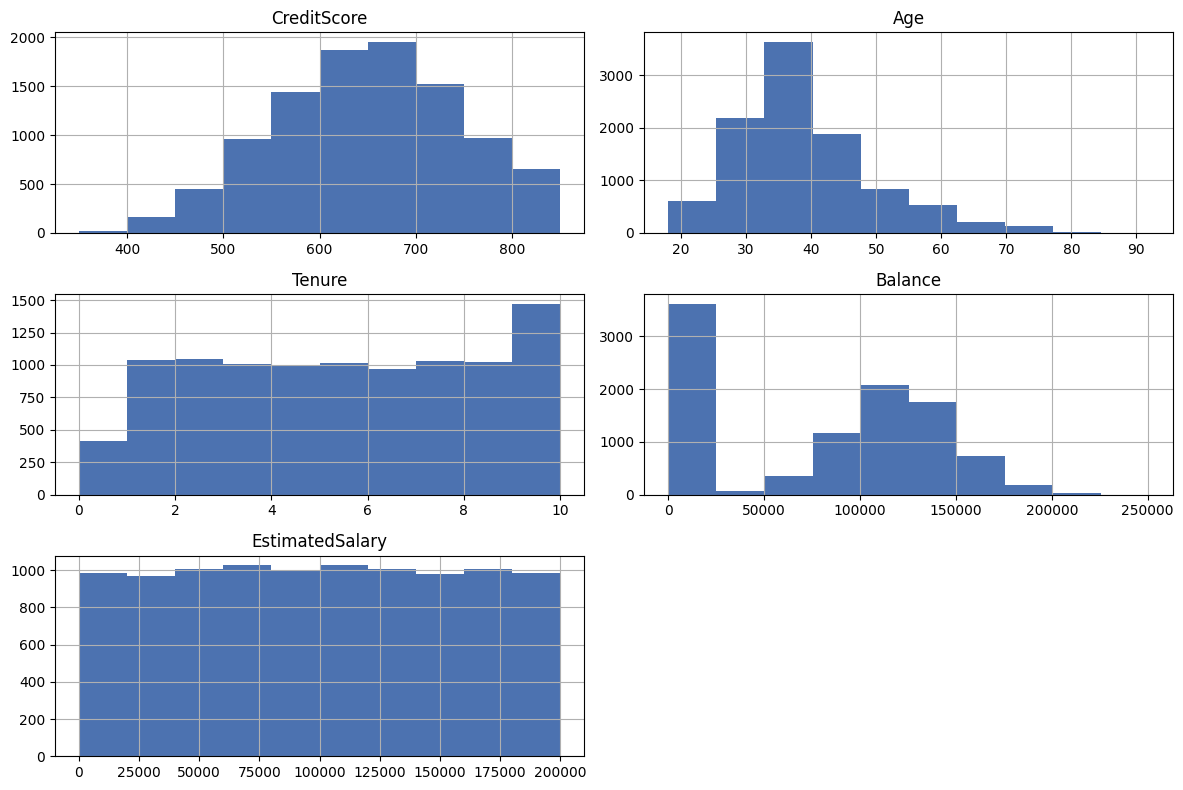

In [17]:
import matplotlib.pyplot as plt

# continuous numerical features
numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

df[numerical_features].hist(figsize=(12,8), color="#4C72B0")

plt.tight_layout()
plt.show()

**Observation:** Continuous Feature Distributions 

- **CreditScore:** Approximately normally distributed around mid range values.
- **Age:** Right-skewed, and majority between 30–45 years.
- **Tenure:** uniformly distributed across years showing no strong concentration in a specific range.
- **Balance:** Bimodal, many customers have zero balance and others around mid high range.
- **EstimatedSalary:** salary values are evenly spread across the range showing no strong concentration in a specific income level.

##### **Feature Distributions (Proportions)**
Proportion bar plots show how binary and categorical features are distributed by displaying the percentage of each category instead of raw counts. This helps identify balance or imbalance between categories within the dataset.

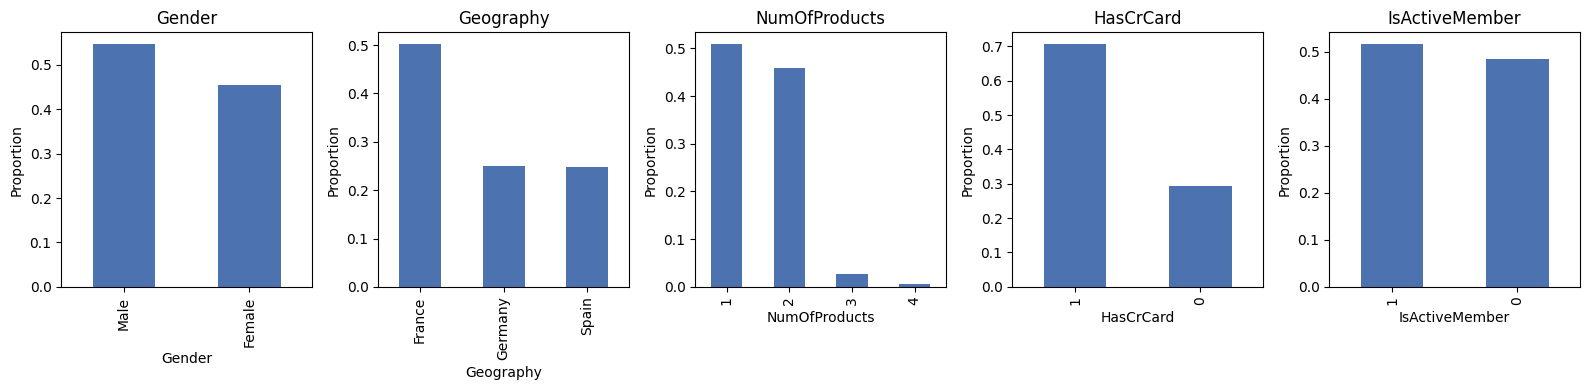

In [18]:
import matplotlib.pyplot as plt

categorical_features = [
    'Gender',
    'Geography',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'
]

plt.figure(figsize=(16,4))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(1, len(categorical_features), i)

    proportions = df[col].value_counts(normalize=True)
    proportions.plot(kind='bar', color="#4C72B0")

    plt.title(col)
    plt.ylabel("Proportion")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**Observation:** Binary & Categorical Feature Distributions

- **Gender:** The distribution between male and female customers is relatively balanced with the males having slightly higher percentage, allowing fair comparison between the two groups.
- **Geography:** Customers are distributed across multiple regions (France, Germany, and Spain), indicating representation from different geographic markets.
- **NumOfProducts:** Most customers hold 1 or 2 products, while fewer customers have higher numbers of products.
- **HasCrCard:** The majority of customers own a credit card.
- **IsActiveMember:** Customers are relatively evenly distributed between active and inactive members, enabling meaningful comparison between activity levels.

##### **Box Plots for Continues Features**
A box plot is a visualization that summarizes the distribution of a continuous numerical feature, We use box plots for continuous features ( Age, Balance, Tenure, CreditScore, EstimatedSalary) because they clearly show spread, central tendency, and potential outliers.
We will also use box plots to show relationships between continuous features and the target variable (Exited) by comparing the distributions of churned (1) and stayed (0) customers. 
Differences in medians or spread may indicate that the feature influences churn.

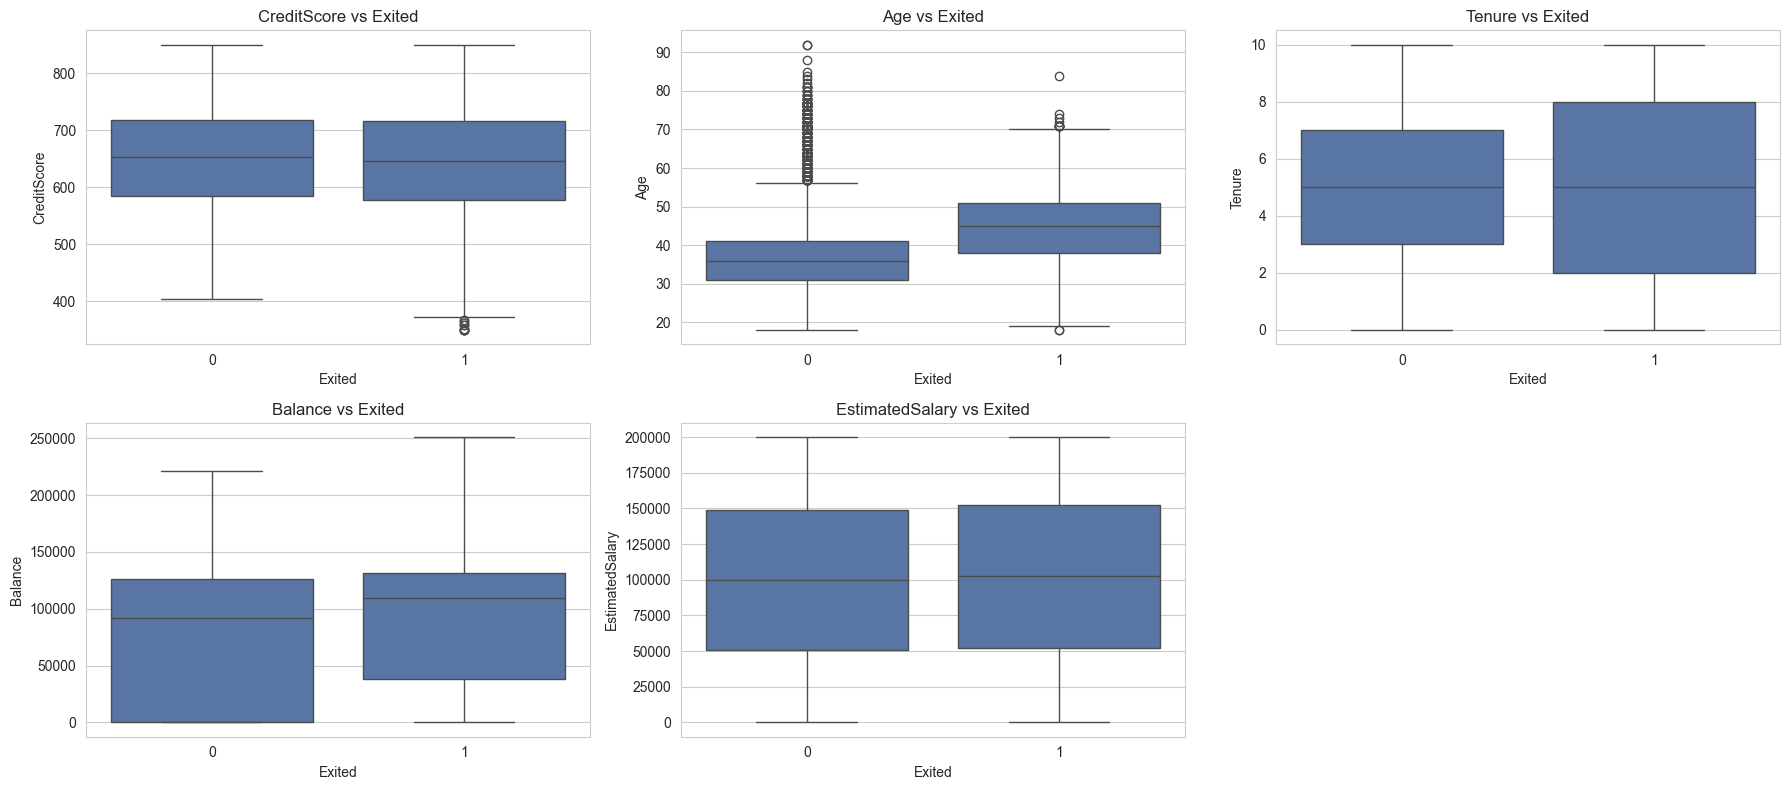

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")

# Remove ID columns
df_plot = df.drop(columns=["RowNumber", "CustomerId"], errors="ignore")

continuous = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

cols = 3
rows = math.ceil(len(continuous) / cols)

plt.figure(figsize=(cols*6, rows*4))

for i, col in enumerate(continuous, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x="Exited", y=col, data=df_plot, color="#4C72B0")
    plt.title(f"{col} vs Exited")

plt.tight_layout()
plt.show()

**Observation:** Continuous Features vs Exited 

- **CreditScore:** Slightly lower for churned customers but strong overlap exists.
- **Age:** Churned customers are generally older.
- **Tenure:** Very similar distributions so it has weak impact on churn.
- **Balance:** Higher balances are associated with higher churn.
- **EstimatedSalary:** Very identical across groups minimal influence.

Overall Age and Balance show clearer differences compared to other continuous features.

##### **Countplots for Categorical & Binary Features**
A count plot is a visualization that shows the distribution of categorical and binary features by displaying the frequency of each category. We use count plots for categorical and binary features distribution (Geography, Gender, NumOfProducts, HasCrCard, IsActiveMember) because these features represent discrete groups rather than continuous values. We will also use count plots to show relationships between categorical/binary features and the target variable (Exited) by comparing churned (1) and stayed (0) customers within each category. Differences in churn proportions may indicate that the feature influences churn.

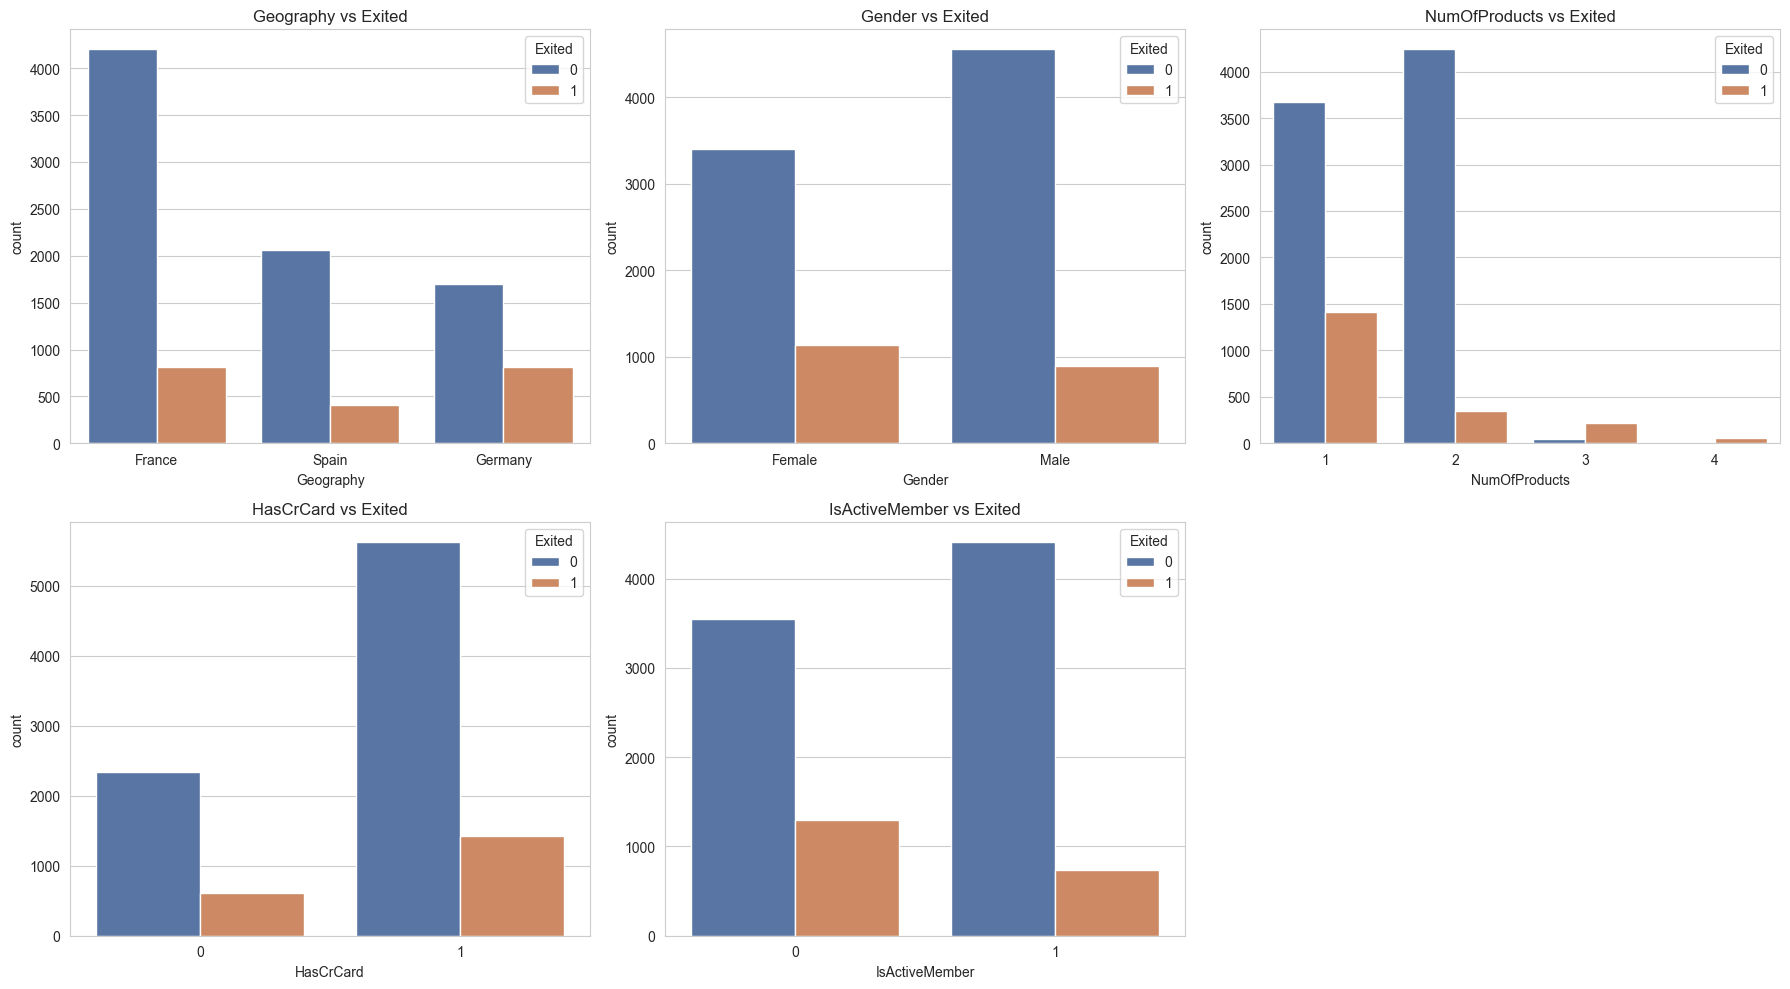

In [20]:
plt.figure(figsize=(18,10))

categorical = ["Geography", "Gender", "NumOfProducts", 
               "HasCrCard", "IsActiveMember"]

cols = 3
rows = math.ceil(len(categorical) / cols)

for i, col in enumerate(categorical, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(x=col, hue="Exited", data=df_plot,
                  palette=["#4C72B0", "#DD8452"])
    plt.title(f"{col} vs Exited")

plt.tight_layout()
plt.show()

**Observation:** Categorical & Binary Features vs Exited 

- **Geography:** Churn rates vary by region Germany shows higher churn proportion.
- **Gender:** Females shows higher churn.
- **NumOfProducts:** Customers with 3+ products churn more and 2- product customers churn less.
- **HasCrCard:** Churn rates are similar for customers with and without a credit card which indicate no strong impact on churn.
- **IsActiveMember:** Inactive members are more likely to churn.

Overall IsActiveMember and NumOfProducts show the strongest categorical relationships with churn.


### **4.3 Visualization**

In this subsection we use visual techniques to better understand feature relationships, and potential predictive importance. Visualizations help identify patterns that may not be obvious from numerical summaries alone.

##### **Correlation Heatmap**

A correlation heatmap is a visual representation of the correlation matrix -in subsection 4.2- that shows the strength and direction of linear relationships between numerical features.
We will use it to quickly and visually identify which features are positively or negatively associated with the target variable (Exited).

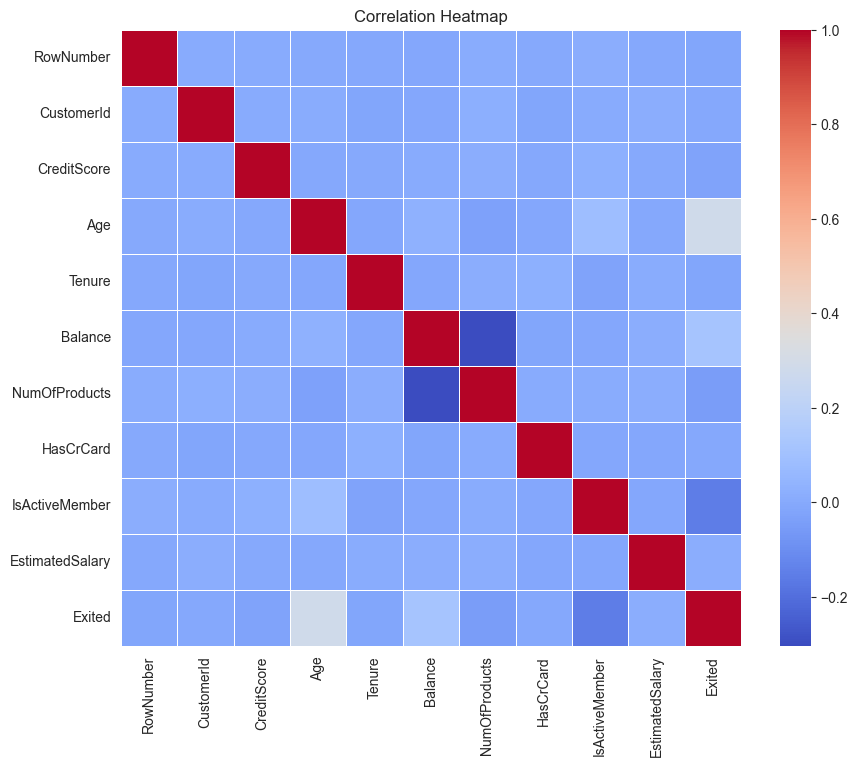

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=False, 
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

**Observation:**  The heatmap shows generally weak correlations between most features and the target variable (Exited). Age has the strongest positive correlation with churn while IsActiveMember shows a noticeable negative correlation. There is also a moderate negative correlation between Balance and NumOfProducts. Overall no single feature strongly explains churn indicating that multiple factors contribute to customer exit.

##### **Class Distribution Plot**
A class distribution plot visualizes the frequency of each class in the target variable.
We use it to understand whether the dataset is balanced or imbalanced, which is important for model evaluation and selection of appropriate performance metrics.

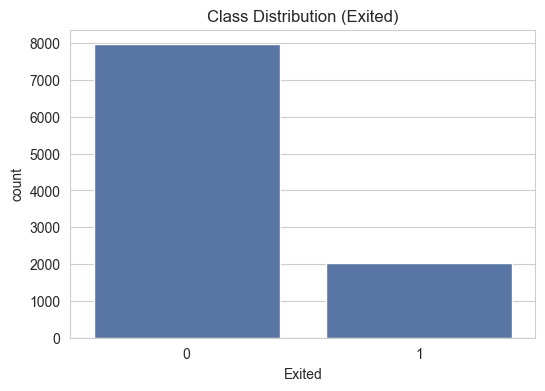

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df, color="#4C72B0")
plt.title("Class Distribution (Exited)")
plt.show()

**Observation:** The class distribution plot visualise a clear imbalance in the target variable - noticed in subsection 4.1-, with more customers staying (Exited = 0) than churning (Exited = 1). This imbalance should be considered when training and evaluating predictive models.

##### **Feature Variance Plot**

A feature variance plot visualizes how much each numerical feature varies across the dataset. We use it to understand the spread of the variables and identify features with very high or very low variability before modeling. **Gender** and **Geography** were'nt added because variance is calculated only for numerical variables.



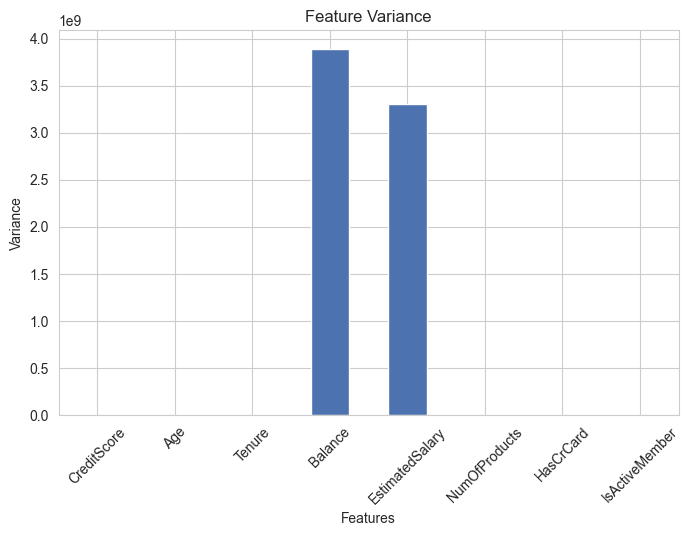

In [44]:
import matplotlib.pyplot as plt

selected_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',

]

variance = df[selected_features].var()

plt.figure(figsize=(8,5))
variance.plot(kind='bar', color='#4C72B0')

plt.title("Feature Variance")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.xticks(rotation=45)

plt.show()

**Observation:**  The plot shows that **Balance** and **EstimatedSalary** have significantly higher variance compared to the other features and can be refered to as high-magnitude features, indicating a much wider range of values across customers. Features such as **CreditScore, Age, Tenure, NumOfProducts, HasCrCard, and IsActiveMember** show relatively low variance because their values are more limited or discrete. This highlights that financial variables tend to vary more across customers than behavioral or binary attributes.


---

## **5. Preprocessing & Feature Engineering**

This section applies a clean, reproducible preprocessing pipeline and explains why each step is needed.

### Pipeline Summary

1. Remove identifiers  
2. Handle missing values and duplicates  
3. Engineer behavioral and interaction features  
4. Apply selective `log1p` to highly skewed variables  
5. One-hot encode categorical variables  
6. Standardize numeric predictors  
7. Handle class imbalance with SMOTE  
8. Export processed dataset


### **5.0 Import Libraries and Load Data**


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Dataset/Raw_Churn_Modelling_Data.csv')
print('Initial shape:', df.shape)
df.head()

Initial shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### **5.1 Remove Identifier Columns**

**Objective**

- Remove identifier fields that should not be used as predictors.

**Method**

- Drop `RowNumber`, `CustomerId`, and `Surname`.

**Rationale**

- These are identifiers, not behavioral signals.
- Keeping them can introduce noise without improving predictive performance.

In [ ]:
id_cols = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=id_cols)
print('Shape after removing identifier columns:', df.shape)
df.head()

Shape after removing identifier columns: (10000, 16)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,AgeGroup,ActiveBalance,InactiveHighBalance,LogCustomerValue
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,40_49,0.00,0,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,40_49,83807.86,0,11.336294
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,40_49,0.00,1,13.079421
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,30_39,0.00,0,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,40_49,125510.82,0,11.740155


### **5.2 Missing Values and Duplicate Handling**

**Objective**

- Clean null values and duplicate records before feature creation.

**Method**

- Numeric columns: median imputation. (None here)
- Categorical columns: mode imputation. (None here)
- Remove duplicate rows. (None here)

**Rationale**

- Median is robust to outliers in numeric variables.
- Mode preserves valid category values.
- Deduplication prevents repeated rows from biasing learning.

In [ ]:
print('Missing values before handling:')
print(df.isnull().sum())
print('Duplicate rows before handling:', df.duplicated().sum())

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates().reset_index(drop=True)

print('Missing values after handling:')
print(df.isnull().sum())
print('Duplicate rows after handling:', df.duplicated().sum())

Missing values before handling:
RowNumber              0
CustomerId             0
Surname                0
CreditScore            0
Geography              0
Gender                 0
Age                    0
Tenure                 0
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Exited                 0
HasBalance             0
AgeGroup               0
ActiveBalance          0
InactiveHighBalance    0
LogCustomerValue       0
dtype: int64
Duplicate rows before handling: 0
Missing values after handling:
RowNumber              0
CustomerId             0
Surname                0
CreditScore            0
Geography              0
Gender                 0
Age                    0
Tenure                 0
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Exited                 0
HasBalance             0
AgeGroup               0
ActiveBalance  

### **5.3 Feature Engineering**

**Objective**

- Create stronger predictors that capture customer behavior and financial risk.

**Method**

- Add engineered features:
  - `HasBalance = (Balance > 0)`
  - `AgeGroup` from age bins
  - `ActiveBalance = Balance * IsActiveMember`
  - `CustomerValue = Balance * NumOfProducts`
  - `InactiveHighBalance = (Balance > 0 and IsActiveMember == 0)`

**Rationale**

- `HasBalance`: Distinguishes customers with active funds in the account from those with zero balance, which may indicate lower engagement with the bank.
- `AgeGroup`: Groups customers into interpretable life-stage segments, allowing models to capture non-linear churn patterns related to age.
- `ActiveBalance`: Combines financial value with account activity, identifying customers who hold funds but may not actively engage with the bank.
- `CustomerValue`: Approximates the overall financial value of a customer by combining balance with the number of products held.
- `InactiveHighBalance`: Flags customers who maintain a positive balance but are inactive, which may signal disengagement and potential churn risk.

In [ ]:
df['HasBalance'] = (df['Balance'] > 0).astype(int)

age_bins = [17, 29, 39, 49, 59, 120]
age_labels = ['18_29', '30_39', '40_49', '50_59', '60_plus']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

df['ActiveBalance'] = df['Balance'] * df['IsActiveMember']
df['CustomerValue'] = df['Balance'] * df['NumOfProducts']
df['InactiveHighBalance'] = ((df['Balance'] > 0) & (df['IsActiveMember'] == 0)).astype(int)

df[['HasBalance', 'AgeGroup', 'ActiveBalance', 'CustomerValue', 'InactiveHighBalance']].head()

,HasBalance,AgeGroup,ActiveBalance,CustomerValue,InactiveHighBalance
0,0,40_49,0.00,0.00,0
1,1,40_49,83807.86,83807.86,0
2,1,40_49,0.00,478982.40,1
3,0,30_39,0.00,0.00,0
4,1,40_49,125510.82,125510.82,0


### **5.4 Selective Log Transformation (TENTATIVE)**

**Objective**

- Apply `log1p` only to positively skewed (right-skew) continuous features.

**Method**

- Compute skewness for `BalanceSalaryRatio`, and `CustomerValue`.
- Apply `np.log1p()` to features with skewness greater than `0.75`.
- Drop original versions when a log-transformed version is created.

**Rationale**

- This stabilizes variance for highly skewed variables without transforming features that are already well-behaved.

In [ ]:
skew_candidates = ['CustomerValue']
skew_values = df[skew_candidates].skew()
skewed_cols = [col for col in skew_candidates if skew_values[col] > 0.75]

for col in skewed_cols:
    df[f'Log{col}'] = np.log1p(df[col].clip(lower=0))

df = df.drop(columns=skewed_cols)

print('Skewness before log transform:')
print(skew_values)
print('Columns transformed with log1p:', skewed_cols)
df[['LogCustomerValue']].head()

Skewness before log transform:
CustomerValue    0.955687
dtype: float64
Columns transformed with log1p: ['CustomerValue']


,LogCustomerValue
0,0.000000
1,11.336294
2,13.079421
3,0.000000
4,11.740155


### **5.5 Categorical Encoding**
**Objective**
- Convert categorical variables into numeric format for machine learning models.

**Method**
- One-hot encode `Geography`, `Gender`, and `AgeGroup` using `pd.get_dummies(..., drop_first=True)`.

**Rationale**
- Models cannot directly process string categories.
- One-hot encoding avoids false ordinal assumptions.
- `drop_first=True` reduces redundant dummy columns.

In [ ]:
categorical_cols = ['Geography', 'Gender', 'AgeGroup']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print('Shape after encoding:', df_encoded.shape)
df_encoded.head()


Shape after encoding: (10000, 23)


,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,...,ActiveBalance,InactiveHighBalance,LogCustomerValue,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,...,0.00,0,0.000000,0,0,0,0,1,0,0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,...,83807.86,0,11.336294,0,1,0,0,1,0,0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,...,0.00,1,13.079421,0,0,0,0,1,0,0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,...,0.00,0,0.000000,0,0,0,1,0,0,0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,...,125510.82,0,11.740155,0,1,0,0,1,0,0


### **5.6 Feature Scaling (Z-score Standardization)**
**Objective**
- Standardize numeric predictors so no high-magnitude feature dominates model learning.

**Method**
- Use `StandardScaler()` on all numeric columns except target `Exited`.

**Rationale**
- Scaling improves optimization and distance behavior for models such as Logistic Regression, SVM, and KNN.


In [ ]:
target_col = 'Exited'
numeric_cols = df_encoded.select_dtypes(include=['number']).columns.tolist()
feature_scale_cols = [col for col in numeric_cols if col != target_col]

scaler = StandardScaler()
df_encoded[feature_scale_cols] = scaler.fit_transform(df_encoded[feature_scale_cols])

print('Scaled feature count:', len(feature_scale_cols))
print(df_encoded[feature_scale_cols].describe().loc[['mean', 'std']].head())
# Remove identifier columns before SMOTE/export
id_cols = ['RowNumber', 'CustomerId', 'Surname']
df_encoded = df_encoded.drop(columns=id_cols, errors='ignore')

# Quick check: no text columns should remain
print(df_encoded.select_dtypes(include='object').columns)
print(df_encoded.shape)


Scaled feature count: 21
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
mean -4.547474e-17  2.131628e-17 -2.415845e-17  3.552714e-19 -6.288303e-17   
std   1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00   

           Balance  NumOfProducts     HasCrCard  IsActiveMember  \
mean -1.705303e-17   7.460699e-18 -5.258016e-17   -3.623768e-17   
std   1.000050e+00   1.000050e+00  1.000050e+00    1.000050e+00   

      EstimatedSalary  ...  ActiveBalance  InactiveHighBalance  \
mean    -1.438849e-17  ...   3.197442e-17        -3.126388e-17   
std      1.000050e+00  ...   1.000050e+00         1.000050e+00   

      LogCustomerValue  Geography_Germany  Geography_Spain   Gender_Male  \
mean     -2.984279e-17       6.679102e-17    -6.394885e-18  2.131628e-18   
std       1.000050e+00       1.000050e+00     1.000050e+00  1.000050e+00   

      AgeGroup_30_39  AgeGroup_40_49  AgeGroup_50_59  AgeGroup_60_plus  
mean    3.890221e-17    4.334311e-17 

### **5.7 Class Imbalance Handling**
**Objective**
- Address churn class imbalance before model training.

**Method**
- Split features and target (`X`, `y`) from `df_encoded`.
- Apply `SMOTE(random_state=42)` to generate synthetic samples of the minority class.
- Create balanced datasets `X_resampled` and `y_resampled`.
- Compare class distribution before and after resampling.

**Rationale**
- The churn target is imbalanced (approximately 80% non-churn and 20% churn).
- SMOTE generates synthetic minority samples, helping the model learn churn patterns more effectively and reducing bias toward the majority class.

In [ ]:
target_col = 'Exited'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print('Class distribution (raw):')
print(y.value_counts(normalize=True).rename('proportion'))

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print('Class distribution (after SMOTE):')
print(y_resampled.value_counts(normalize=True).rename('proportion'))

Class distribution (raw):
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64
Class distribution (after SMOTE):
Exited
1    0.5
0    0.5
Name: proportion, dtype: float64


/Users/laylakhaled/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


### **5.8 Export Final Preprocessed Dataset**


In [ ]:
output_path = 'Dataset/Preprocessed_Churn_Modelling_Data.csv'
df_encoded.to_csv(output_path, index=False)

print('Final preprocessed shape:', df_encoded.shape)
print('Saved file:', output_path)
df_encoded.head()


Final preprocessed shape: (10000, 20)
Saved file: Dataset/Preprocessed_Churn_Modelling_Data.csv


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,LogCustomerValue,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0,0.752769,0.763198,-0.671064,0.650691,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1,0.752769,-0.666937,1.490172,0.954597,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,1.140599,-0.595522,-0.308497,-0.235628
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,0,0.752769,1.474836,-0.671064,0.721102,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
